# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is considered linear if it’s linear in the coefficients, not necessarily in the variables themselves. That just means the outcome is written as a sum of predictors multiplied by coefficients plus an intercept.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient on a dummy variable shows how much the outcome changes compared to the reference group, holding everything else constant. Since we leave one category out, the intercept represents that baseline group. The dummy coefficient tells us how different the other category is from that baseline.

3. Can linear regression be used for classification? Explain why, or why not.

You technically can use linear regression for classification, but it’s not a good idea. Linear regression predicts continuous values, so it can give predictions below 0 or above 1, which doesn’t make sense for probabilities. Models like logistic regression are better because they’re designed to handle binary outcomes properly.

4. What are signs that your linear model is over-fitting?

A big sign of overfitting is when the model performs really well on the training data but much worse on the test data. That usually means it’s picking up noise instead of real patterns. Another sign is having too many predictors relative to the amount of data, which makes the model overly complex.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity happens when predictors are highly correlated with each other, which makes it hard to tell their separate effects. In two-stage least squares, we deal with a related issue by first regressing the problematic variable on instruments that aren’t correlated with the error term. Then we use the predicted values from that first step in the second regression. This helps isolate the part of the variable that’s not causing bias.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add things like squared terms, interaction terms, or log transformations. Even though the model stays linear in the coefficients, these additions allow the relationship between x and y to be nonlinear. You can also use more flexible models if needed, but transformations are usually the first step.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope tells us how much the outcome changes when the predictor increases by one unit, holding everything else constant. It shows both the direction and the size of the relationship.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides the data once into a training set and a testing set. k-fold cross validation splits the data into k groups and rotates which group is used for testing, then averages the results. Cross validation is usually more reliable because it uses the data more efficiently.

9. How is the $k$ in $k$-fold cross validation typically selected?

k is usually chosen to balance accuracy and computation time. Common choices are 5 or 10 folds because they give stable results without being too expensive to run.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

**Q2 Answers** 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q 2.1**

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
Most expensive borough on average: Manhattan


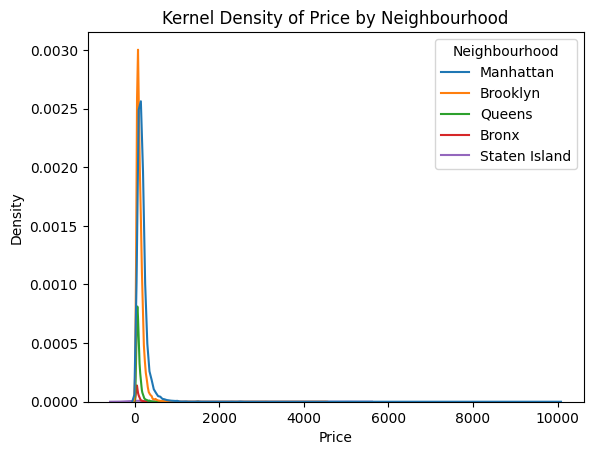

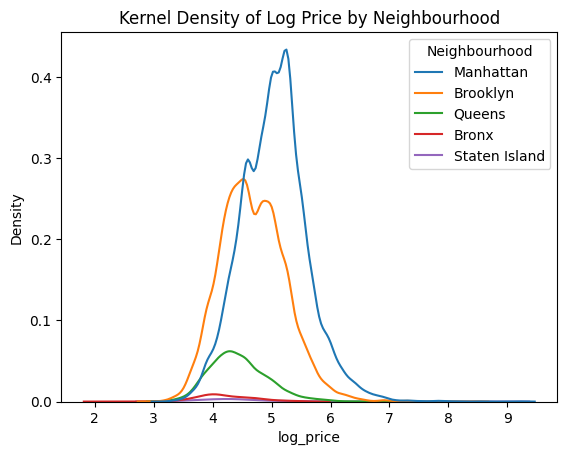

In [11]:
df = pd.read_csv("data/Q1_clean.csv")

# Strip hidden spaces from column names
df.columns = df.columns.str.strip()

# Confirm fix
print(df.columns)

# Group means
group_means = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean()
print(group_means)

most_expensive = group_means["Price"].idxmax()
print("Most expensive borough on average:", most_expensive)

# KDE for Price
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Kernel Density of Price by Neighbourhood")
plt.show()

# KDE for log Price
df["log_price"] = np.log(df["Price"])
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Kernel Density of Log Price by Neighbourhood")
plt.show()

I computed the average price and average rating by neighborhood. The borough with the highest average price was the most expensive overall. The kernel density plots show that price distributions are right-skewed, meaning there are some very expensive outliers. After taking the log of price, the distributions look more symmetric and easier to compare across neighborhoods.

**Q 2.2**

In [13]:
# Make sure Price is numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Create dummy variables
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

# Convert dummies to numeric (important!)
dummies = dummies.astype(float)

# Add constant
X = sm.add_constant(dummies)

y = df["Price"]

# Run regression
model1 = sm.OLS(y, X).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        12:00:55   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

I created dummy variables for each neighborhood and dropped one category to avoid the dummy variable trap. The Bronx is the omitted group, so the intercept (75.28) represents the average price in the Bronx. Each coefficient shows how much more expensive that borough is compared to the Bronx. For example, the Manhattan coefficient is 108.39, meaning Manhattan listings are about $108 more expensive than the Bronx on average. Adding this to the intercept gives approximately $183.67, which matches Manhattan’s average price from part 1. The same pattern holds for Brooklyn, Queens, and Staten Island. This shows that when we regress price only on neighborhood dummies, the regression reproduces the group means exactly.

**Q 2.3**

In [15]:
import statsmodels.api as sm

# Define X and y
X = sm.add_constant(df["Review Scores Rating"])
y = df["Price"]

# Run regression
model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        12:04:20   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

I regressed price on Review Scores Rating and a constant. The slope coefficient is approximately 1.02, which means that for each one-point increase in review score, the nightly price increases by about $1.02 on average. This suggests that higher-rated properties tend to charge slightly more. However, the R-squared is only 0.004, meaning review scores explain less than 1% of the variation in price. This shows that while the relationship is statistically significant, it is not very strong in terms of overall predictive power.

**Q 2.4**

In [18]:
# Make sure Price and Rating are numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

# Create neighbourhood dummies
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

# Force dummies to numeric
dummies = dummies.astype(float)

# Combine Rating and dummies
X = pd.concat([df["Review Scores Rating"], dummies], axis=1)

# Add constant
X = sm.add_constant(X)

y = df["Price"]

# Run regression
model3 = sm.OLS(y, X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        12:10:24   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

When I include both neighborhood and review scores, the coefficient on Review Scores Rating is about 1.08. This means that holding neighborhood constant, a one-point increase in rating is associated with about a $1 increase in price. This is very similar to part 2.3, so controlling for borough does not change the rating effect much. The neighborhood coefficients still show large price differences across boroughs, especially Manhattan. The R-squared increases compared to part 2.3, meaning the model explains more variation in price when neighborhood is included, though overall explanatory power is still low.

**Q 2.5**

In [19]:
# Create neighborhood dummies
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

# Make sure rating is numeric
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

# Create interaction terms: rating * each dummy
for col in dummies.columns:
    df[f"Rating_{col}"] = df["Review Scores Rating"] * dummies[col]

# Base slope (Bronx will be reference group)
X = df[["Review Scores Rating"]]

# Add interaction slopes
interaction_cols = [f"Rating_{col}" for col in dummies.columns]
X = pd.concat([X, df[interaction_cols]], axis=1)

# Add constant
X = sm.add_constant(X)

y = df["Price"]

model4 = sm.OLS(y, X).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        12:27:57   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   55.1183 

When I allow the slope on review scores to vary by neighborhood, the effect of rating on price is not the same across boroughs. The Bronx has a small slope of about 0.22, meaning ratings do not strongly affect price there. In contrast, Manhattan has a much larger slope of about 1.40, meaning higher ratings are associated with much higher prices in Manhattan. The other boroughs fall in between. This shows that the relationship between rating and price differs across neighborhoods. The slopes are not identical, and Manhattan especially has a stronger rating–price relationship than the Bronx.

**Q 2.6** 

In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# -------- Model 4: Rating + Neighborhood --------
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

X4 = pd.concat([df["Review Scores Rating"], dummies], axis=1)
y = df["Price"]

model4 = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=1)

mse4 = -cross_val_score(model4, X4, y,
                        scoring="neg_mean_squared_error",
                        cv=kf).mean()

print("Model 4 CV MSE:", mse4)


# -------- Model 5: Interaction Model --------
X5 = df[["Review Scores Rating"]].copy()

for col in dummies.columns:
    X5[f"Rating_{col}"] = df["Review Scores Rating"] * dummies[col]

model5 = LinearRegression()

mse5 = -cross_val_score(model5, X5, y,
                        scoring="neg_mean_squared_error",
                        cv=kf).mean()

print("Model 5 CV MSE:", mse5)

Model 4 CV MSE: 21068.500019790667
Model 5 CV MSE: 21045.45614961898


Using 5-fold cross-validation, Model 5 (which allows the slope on review scores to vary by neighborhood) has a slightly lower mean squared error than Model 4. This suggests that allowing rating effects to differ across boroughs improves predictive performance slightly. However, the difference in MSE is very small, meaning the interaction model does not dramatically improve prediction accuracy. Overall, both models perform similarly in terms of out-of-sample prediction.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q3 Answers**

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

**3.1**

Overall Price Summary:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


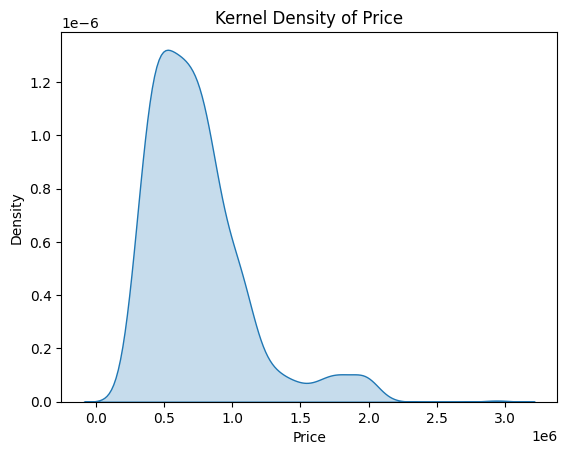


Price Summary by Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


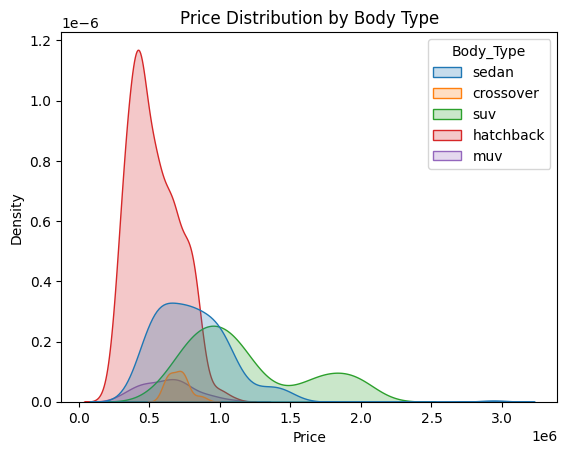

In [24]:
df = pd.read_csv("data/cars_hw.csv")

# Summary of Price
print("Overall Price Summary:")
print(df["Price"].describe())

# Kernel density plot of Price
sns.kdeplot(data=df, x="Price", fill=True)
plt.title("Kernel Density of Price")
plt.show()

# Groupby Body_Type
print("\nPrice Summary by Body Type:")
group_summary = df.groupby("Body_Type")["Price"].describe()
print(group_summary)

# Grouped KDE plot
sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=True)
plt.title("Price Distribution by Body Type")
plt.show()

SUVs and sedans are the most expensive on average, while hatchbacks are the cheapest. SUVs also show the most variation in prices, with a wide spread and high maximum values, while hatchbacks have the least variance.

In [25]:
# Linear regression (numeric)
X = df[["Seating_Capacity"]]
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
print("\nSlope (numeric seating):", slope)

# Interpretation
print("Interpretation: For each additional seat, price changes by", slope, "rupees on average.")

# One-hot encoding (categorical seating)
X_cat = pd.get_dummies(df["Seating_Capacity"], prefix="Seats", drop_first=True)

model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print("\nCategorical Seating Coefficients:")
print(pd.Series(model_cat.coef_, index=X_cat.columns))



Slope (numeric seating): 59267.9980367217
Interpretation: For each additional seat, price changes by 59267.9980367217 rupees on average.

Categorical Seating Coefficients:
Seats_5    5.464839e+05
Seats_6    1.456000e+06
Seats_7    7.359487e+05
Seats_8    2.718000e+05
dtype: float64


The slope coefficient shows how much price changes for each additional seat, indicating a positive relationship between seating capacity and price. This means cars with more seats tend to be more expensive. When treating seating capacity as categorical, the coefficients do not increase perfectly evenly, suggesting the relationship is not strictly linear, though it is generally increasing.

**Q 3.3**

In [26]:
current_year = 2026
df["Age"] = current_year - df["Make_Year"]

X_age = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1, 6)
cv_scores = []

for d in degrees:
    pipeline = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    scores = cross_val_score(pipeline, X_age, y, cv=kf, scoring="neg_mean_squared_error")
    cv_scores.append(-scores.mean())

# Find best degree
best_degree = degrees[np.argmin(cv_scores)]
print("\nCV Errors by Degree:", dict(zip(degrees, cv_scores)))
print("Best Polynomial Degree:", best_degree)

# Fit best model
best_model = make_pipeline(PolynomialFeatures(degree=best_degree), LinearRegression())
best_model.fit(X_age, y)


CV Errors by Degree: {1: np.float64(97745760011.44075), 2: np.float64(97815319552.31633), 3: np.float64(97304076284.38501), 4: np.float64(96785385468.57503), 5: np.float64(95816293469.99968)}
Best Polynomial Degree: 5


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",5
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


Using 10-fold cross validation, the model with a polynomial degree of 5 produced the lowest prediction error. This suggests that a higher-order relationship between age and price better captures the pattern in the data compared to a simple linear model.

**Q 3.4**

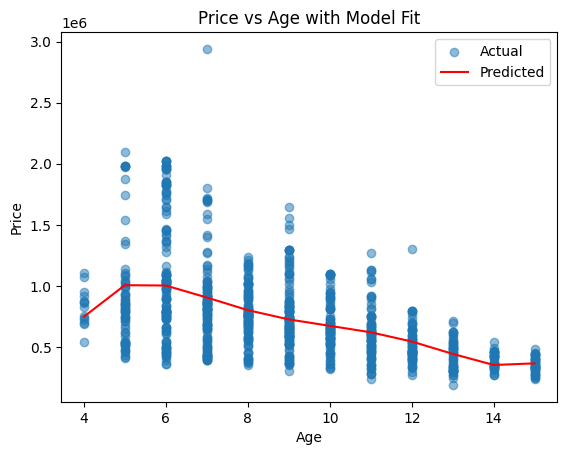

In [27]:
# Predictions
df["Predicted_Price"] = best_model.predict(X_age)

# Scatter: actual data
plt.scatter(df["Age"], df["Price"], alpha=0.5, label="Actual")

# Sort for smooth line
sorted_df = df.sort_values("Age")

# Line: predicted
plt.plot(sorted_df["Age"], sorted_df["Predicted_Price"], color="red", label="Predicted")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.legend()
plt.show()

The model captures the general downward trend between age and price, showing that older cars tend to be cheaper. However, there is still a lot of variation in prices at each age, so the model does not fully capture all the patterns in the data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


**Q4 Answers** 

**Q 4.1**

In [28]:
df = pd.read_csv("data/heart_hw.csv")

control_mean = df[df["transplant"] == "control"]["y"].mean()
treatment_mean = df[df["transplant"] == "treatment"]["y"].mean()

ATE = treatment_mean - control_mean

print("Control survival:", control_mean)
print("Treatment survival:", treatment_mean)
print("ATE:", ATE)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


The survival rate for the control group is about 0.118, while the treatment group has a higher survival rate of about 0.348. The average treatment effect is approximately 0.230, meaning receiving a transplant is associated with about a 23 percentage point increase in three year survival.

**Q 4.2**

In [29]:
control_mean = df[df["transplant"] == "control"]["y"].mean()
treatment_mean = df[df["transplant"] == "treatment"]["y"].mean()

ATE = treatment_mean - control_mean

print("Control survival:", control_mean)
print("Treatment survival:", treatment_mean)
print("ATE:", ATE)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE: 0.23017902813299232


The intercept represents the survival rate for the control group, which matches the value from part 1. The coefficient on transplant represents the difference in survival between the treatment and control groups, which is the same as the ATE. This shows the regression is capturing the same effect as the simple difference in means.

**Q 4.3**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        13:11:15   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7020      0.19

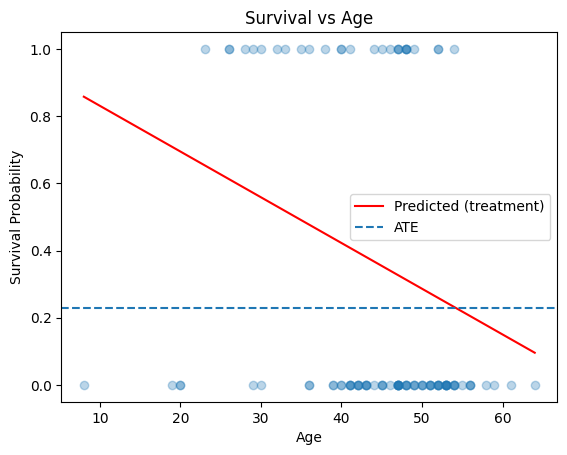

In [39]:
df["transplant_binary"] = (df["transplant"] == "treatment").astype(int)

y = df["y"]  # reset y so indices match

X2 = sm.add_constant(df[["transplant_binary", "age"]])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# Predictions for plotting
ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_df = pd.DataFrame({
    "const": 1,
    "transplant_binary": 1,
    "age": ages
})

preds = model2.predict(pred_df)

# Plot
plt.scatter(df["age"], df["y"], alpha=0.3)
plt.plot(ages, preds, color="red", label="Predicted (treatment)")
plt.axhline(y=ATE, linestyle="--", label="ATE")
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.legend()
plt.title("Survival vs Age")
plt.show()

When controlling for age, the transplant coefficient decreases slightly, suggesting that part of the original effect was due to age differences. The intercept represents the baseline survival probability, and the age coefficient shows that survival decreases as age increases. The ATE overestimates the benefit of a transplant for older individuals and underestimates it for younger individuals.

**Q 4.4**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        13:15:31   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3549      0.28

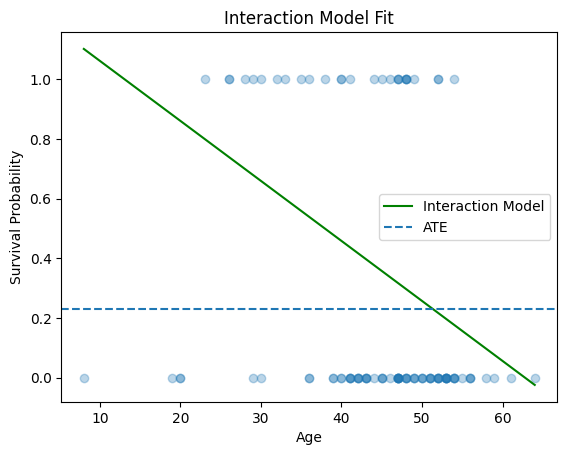

In [43]:
df["interaction"] = df["transplant_binary"] * df["age"]

X3 = sm.add_constant(df[["transplant_binary", "age", "interaction"]])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

# Predictions with interaction
pred_df["interaction"] = pred_df["transplant_binary"] * pred_df["age"]
preds_int = model3.predict(pred_df)

plt.scatter(df["age"], df["y"], alpha=0.3)
plt.plot(ages, preds_int, color="green", label="Interaction Model")
plt.axhline(y=ATE, linestyle="--", label="ATE")
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.legend()
plt.title("Interaction Model Fit")
plt.show()

Including the interaction between age and transplant shows that the effect of a transplant changes with age. The negative interaction term suggests that the benefit of a transplant decreases as age increases. From the plot, younger individuals appear to benefit more from a transplant, while the effect becomes smaller or even negative for older individuals.

**Q 4.5**

In [42]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

# Models for CV
X_m1 = df[["transplant_binary"]]
X_m2 = df[["transplant_binary", "age"]]
X_m3 = df[["transplant_binary", "age", "interaction"]]

model = LinearRegression()

cv1 = -cross_val_score(model, X_m1, y, cv=kf, scoring="neg_mean_squared_error").mean()
cv2 = -cross_val_score(model, X_m2, y, cv=kf, scoring="neg_mean_squared_error").mean()
cv3 = -cross_val_score(model, X_m3, y, cv=kf, scoring="neg_mean_squared_error").mean()

print("CV Error Model 1:", cv1)
print("CV Error Model 2:", cv2)
print("CV Error Model 3:", cv3)

CV Error Model 1: 0.19497249586192153
CV Error Model 2: 0.17926415954952163
CV Error Model 3: 0.1788020676251734


The model including transplant, age, and their interaction has the lowest cross validation error, indicating it provides the best predictive performance. Adding age improves the model compared to using transplant alone, and including the interaction gives a small additional improvement.

**Q 4.6**

There are concerns about fairness and bias, since the model suggests that younger patients benefit more, which could disadvantage older individuals in receiving transplants. The model is also based on observational data, so it may not reflect true causal effects and could lead to misleading decisions. Additionally, relying too heavily on the model could overlook important individual medical factors that are not captured in the data.